In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch


# Adds the parent directory to the python path
sys.path.append(os.path.abspath(".."))

from src.semester_project_subliminal_learning.models import SimpleMLP
from src.semester_project_subliminal_learning.utils import (
    create_fixed_noise_loader,
    distill_student,
    get_dataloaders,
    train_teacher,
)

In [2]:
# ──────────────────────── CONFIGURATION ────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 1024       
LR = 3e-4               # learning rate from the paper
EPOCHS_TEACHER = 10
EPOCHS_STUDENT = 5 
data_dir = "/Users/tomschott/docs/ETH_REPO/Master/Sem3/semester-project-subliminal-learning/data"
print(f"using device {DEVICE}")

using device mps


In [3]:
def perturb_weights(model, epsilon):
    """Adds scaled Gaussian noise to a model's weights in-place."""
    if epsilon == 0.0:
        return # No perturbation needed
        
    with torch.no_grad():
        for param in model.parameters():
            # Generate noise with the same shape as the parameter
            noise = torch.randn_like(param) * epsilon
            # Add the noise directly to the weights
            param.add_(noise)

In [4]:
train_loader, test_loader = get_dataloaders(data_dir,BATCH_SIZE,fashion=True)
noise = create_fixed_noise_loader(61440,BATCH_SIZE,DEVICE)

Generating fixed pseudo-dataset of 61440 noise images...


In [5]:
epsilons_to_test = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0]
breakdown_results = {}
accuracy_results = {}

print("Starting Epsilon Breakdown Experiment...")

for eps in epsilons_to_test:
    print(f"\n{'='*40}")
    print(f"Testing Epsilon: {eps}")
    print(f"{'='*40}")

    torch.manual_seed(SEED)
    
    reference_model = SimpleMLP().to(DEVICE)
    teacher = SimpleMLP().to(DEVICE)
    teacher.load_state_dict(reference_model.state_dict())
    
    student = SimpleMLP().to(DEVICE)
    student.load_state_dict(reference_model.state_dict())
    
    # 1. Perturb the Student
    perturb_weights(student, eps)
    
    # 2. Train Teacher 
    train_teacher(teacher, train_loader, DEVICE, epochs=EPOCHS_TEACHER)
    
    # 3. Distill Student
    history = distill_student(student, teacher, noise, test_loader, DEVICE, epochs=EPOCHS_STUDENT, lr=LR)
    
    # 4. Extract the final matrix from the last epoch
    final_matrix = history[-1]['cka_matrix']
    final_acc = history[-1]['accuracy']
    
    # 5. Extract the matching diagonals for the SimpleMLP hidden layers
    # Index 1 = ReLU 1, Index 3 = ReLU 2, Index 4 = Final Linear Output
    l1_cka = final_matrix[1, 1] 
    l2_cka = final_matrix[3, 3] 
    l3_cka = final_matrix[4, 4] 
    
    # 6. Store the results for the line graph
    breakdown_results[eps] = (l1_cka, l2_cka, l3_cka)
    accuracy_results[eps] = final_acc


Starting Epsilon Breakdown Experiment...

Testing Epsilon: 0.0
Training Teacher on images...
Teacher Epoch 1: Loss 1.0980
Teacher Epoch 2: Loss 0.5426
Teacher Epoch 3: Loss 0.4676
Teacher Epoch 4: Loss 0.4303
Teacher Epoch 5: Loss 0.4036
Teacher Epoch 6: Loss 0.3840
Teacher Epoch 7: Loss 0.3731
Teacher Epoch 8: Loss 0.3567
Teacher Epoch 9: Loss 0.3450
Teacher Epoch 10: Loss 0.3368

Distilling Student on Random Noise...
Student Epoch 1: KL Loss 0.001001
Student (Epoch 1) Accuracy: 20.71%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.17it/s]


Student Epoch 2: KL Loss 0.000248
Student (Epoch 2) Accuracy: 27.26%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.20it/s]


Student Epoch 3: KL Loss 0.000171
Student (Epoch 3) Accuracy: 36.89%


...

| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.03it/s]


Student Epoch 4: KL Loss 1297.990228
Student (Epoch 4) Accuracy: 10.34%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.19it/s]


Student Epoch 5: KL Loss 1198.894356
Student (Epoch 5) Accuracy: 10.13%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.20it/s]


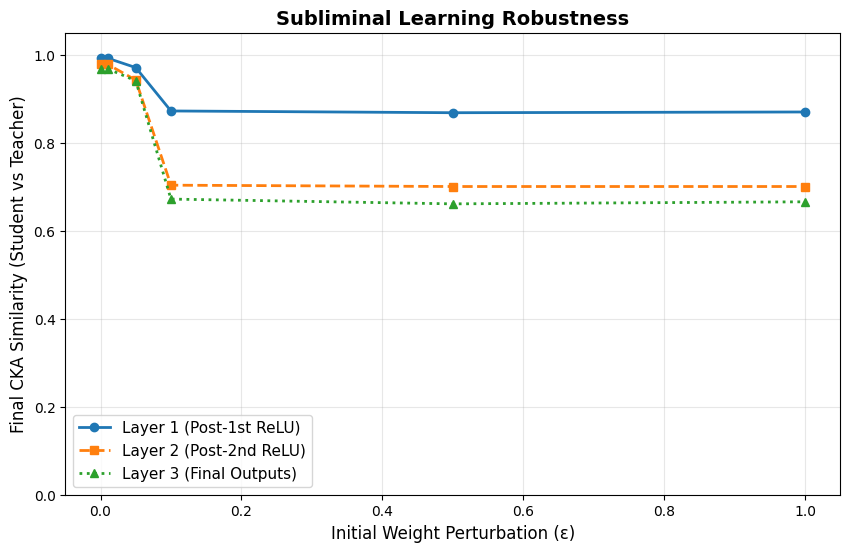

In [6]:
# 1. Extract the x-axis values
epsilons = list(breakdown_results.keys())

# 2. Unpack the tuple values into three separate lists
layer1_cka = [scores[0] for scores in breakdown_results.values()]
layer2_cka = [scores[1] for scores in breakdown_results.values()]
layer3_cka = [scores[2] for scores in breakdown_results.values()]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot each layer with a different marker and color
plt.plot(epsilons, layer1_cka, marker='o', linestyle='-', linewidth=2, label='Layer 1 (Post-1st ReLU)')
plt.plot(epsilons, layer2_cka, marker='s', linestyle='--', linewidth=2, label='Layer 2 (Post-2nd ReLU)')
plt.plot(epsilons, layer3_cka, marker='^', linestyle=':', linewidth=2, label='Layer 3 (Final Outputs)')

plt.title('Subliminal Learning Robustness', fontsize=14, fontweight='bold')
plt.xlabel('Initial Weight Perturbation (\u03B5)', fontsize=12)
plt.ylabel('Final CKA Similarity (Student vs Teacher)', fontsize=12)

# Lock the y-axis between 0 and 1.05 since CKA is a normalized metric
plt.ylim(0.0, 1.05) 

# Add a grid and legend for readability
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(fontsize=11, loc='lower left')

plt.show()

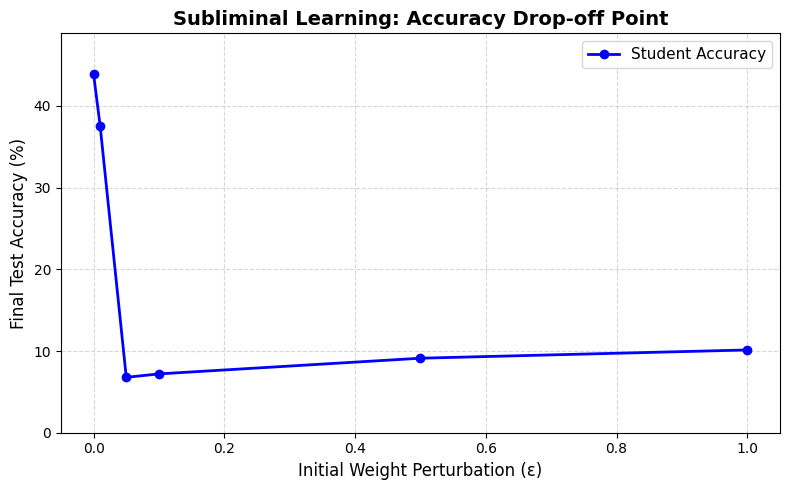

In [7]:
# 1. Extract the x-axis values (epsilons) and y-axis values (accuracies)
epsilons = list(accuracy_results.keys())
accuracies = list(accuracy_results.values())

# 2. Create the plot
plt.figure(figsize=(8, 5))

# Plot the accuracy line
plt.plot(epsilons, accuracies, marker='o', linestyle='-', linewidth=2, color='b', label='Student Accuracy')

# 3. Format the graph
plt.title('Subliminal Learning: Accuracy Drop-off Point', fontsize=14, fontweight='bold')
plt.xlabel('Initial Weight Perturbation (\u03B5)', fontsize=12)
plt.ylabel('Final Test Accuracy (%)', fontsize=12)

# Set the y-axis to comfortably fit percentage values (0 to ~40%)
plt.ylim(0, max(accuracies) + 5) 

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# 4. Display the plot
plt.tight_layout()
plt.show()